<a href="https://colab.research.google.com/github/Aleksandrovna15/Data-Science-Capstone-Project/blob/main/Results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Results, Implications, Challenges
### Alisa Fedorova and Jenna Chiaramonte

In [ ]:
#!pip install sacrebleu
#!pip install unbabel-comet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.4/101.4 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.7/529.7 kB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 64.1 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Fou

In [ ]:
# import libraries and dependencies
import xml.etree.ElementTree as et
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr, levene
import statsmodels.formula.api as smf

import sacrebleu

import comet
from comet import download_model, load_from_checkpoint

TOROT_COLOR   = '#4472C4'
PERSEUS_COLOR = '#C00000'

## Data Loading and Preprocessing

In [ ]:
with open("in_catilinia.txt") as f:
  contents = f.read()
  catilina = contents.split("\n")
  catilina.insert(0, "")
  print(catilina)

['', 'When, O Catiline, do you mean to cease abusing our patience?', 'How long is that madness of yours still to mock us?', 'When is there to be an end of that unbridled audacity of yours, swaggering about as it does now?', 'Do not the nightly guards placed on the Palatine Hill—do not the watches posted throughout the city—does not the alarm of the people, and the union of all good men—does not the precaution taken of assembling the senate in this most defensible place—do not the looks and countenances of this venerable body here present, have any effect upon you?', 'Do you not feel that your plans are detected? Do you not see that your conspiracy is already arrested and rendered powerless by the knowledge which every one here possesses of it?', 'What is there that you did last night, what the night before—where were you—who was there that you summoned to meet you—what design was there which was adopted by you, with which you think that any one of us is unacquainted?', 'Shame on the ag

In [ ]:
with open("in_catilinam.txt") as f:
  contents = f.read()
  catilinam = contents.split("\n")
  catilinam.insert(0, "")
  print(catilinam)

['', 'How much further, Catilina, will you carry your abuse of our forbearance ?', 'How much longer will your reckless temper baffle our restraint ?', 'What bounds will you set to this display of your uncontrolled audacity ?', 'Have you not been impressed by the nightly guards upon the Palatine, by the watching of the city by sentinels ?', 'Are you not affected by the alarm of the people, by the rallying of all loyal citizens, by the convening of the senate in this safely-guarded spot, by the looks and the expressions of all assembled here ?', 'Do you not perceive that your designs are exposed ? Do you not see that your conspiracy is even now fully known and detected by all who are here assembled? What you did last night and the night before, where you were and whom you summoned, and what plans you laid, do you suppose that there is one of us here who does not know ?', 'Alas what degenerate days are these !', 'The senate is well aware of the facts, the consul can perceive them all;', '

In [ ]:
with open("chronicle2.txt") as f:
  contents = f.read()
  chronicle2 = contents.split("\n")
  chronicle2.insert(0, "")
  print(chronicle2)

['', '6453', "In this year, Igor's retinue said to him,", '"The servants of Sveinald are adorned with weapons and fine raiment,', 'but we are naked', 'Go forth with us, oh Prince, after tribute, that both you and we may profit thereby."', "Igor' heeded their words,", 'and he attacked Dereva in search of tribute.', 'He sought to increase the previous tribute ', 'and collected it by violence from the people with the assistance of his followers.', 'After thus gathering the tribute, he returned to his city.', 'On his homeward way, he said to his followers, after some reflection,', '"Go forward with the tribute.', 'I shall turn back,', 'and rejoin you later."', 'He dismissed his retainers on their journey homeward', 'but being desirous of still greater booty he returned on his tracks with a few of his followers.', 'The Derevlians heard that he was again approaching, and consulted with Mal, their prince, saying,', '"If a wolf come among the sheep, he will take away the whole flock one by one

In [ ]:
with open("chronicle3.txt") as f:
  contents = f.read()
  chronicle3 = contents.split("\n")
  chronicle3.insert(0, "")
  print(chronicle3)

['', '6453', 'In this year', 'the retinue said to Igor,', '"Sveinald\'s retainers are clothed with swords and garments,', 'but we are naked.', 'Go, prince, with us after tribute, that you obtain (it) as we."', 'Igor heeded them:', 'he went to Dereva after tribute,', 'and he added to the first tribute.', 'He and his men oppressed them.', 'Having seized the tribute, he returned to his city.', 'Having come back (and) having changed his mind, he said to his retinue,', '"Go home with the tribute.', 'But I will turn back', '(and) will walk back yet again."', 'He sent his retinue home and with a small (part) of his retinue he returned,', 'desiring more possessions.', 'But the Derevlians heard that he (was) coming back, (and) sought counsel with their prince Mal,', '"If a wolf introduces itself among the sheep, then it will make away with the whole flock,', '', 'if they do not kill it. So also (with) this: if we do not kill him, he will destroy us all."', 'They sent to him, saying,', '"For wha

In [ ]:
# read in xml using etree
tree = et.parse("rus.lav.xml")
root = tree.getroot()

In [ ]:
def torot_morphology(morph):

  features = {
      "person": None,
      "number": None,
      "tense": None,
      "mood": None,
      "voice": None,
      "gender": None,
      "case": None,
      "degree": None
  }

  if not morph:
    return features

  morph = morph.ljust(10, "-") # pad if needed
  # mapping positional codings to features
  number_map = {"s": "singular", "p": "plural", "d": "dual"}
  gender_map = {"m": "masculine", "f": "feminine", "n": "neuter"}
  case_map = {
      "n": "nominative",
      "g": "genitive",
      "d": "dative",
      "a": "accusative",
      "i": "instrumental",
      "l": "locative",
      "v": "vocative"
  }

  tense_map = {
      "p": "present",
      "a": "aorist",
      "i": "imperfect",
      "f": "future",
      "r": "perfect"
  }

  mood_map = {
      "i": "indicative",
      "m": "imperative",
      "s": "subjunctive",
      "n": "infinitive"
  }

  voice_map = {
      "a": "active",
      "p": "passive",
      "m": "middle"
  }

  features["person"] = morph[0] if morph[0] in "123" else None
  features["number"] = number_map.get(morph[1])
  features["tense"] = tense_map.get(morph[2])
  features["mood"] = mood_map.get(morph[3])
  features["voice"] = voice_map.get(morph[4])
  features["gender"] = gender_map.get(morph[5])
  features["case"] = case_map.get(morph[6])
  features["degree"] = morph[7] if morph[7] != "-" else None

  return features

In [ ]:
def perseus_morphology(tag):

    features = {
        "pos": None,
        "person": None,
        "number": None,
        "tense": None,
        "mood": None,
        "voice": None,
        "gender": None,
        "case": None,
        "degree": None
    }

    if not tag:
        return features

    tag = tag.ljust(9, "-")

    pos_map = {
        "n": "noun",
        "v": "verb",
        "a": "adjective",
        "p": "pronoun",
        "r": "preposition",
        "d": "adverb",
        "c": "conjunction",
        "u": "punctuation",
        "m": "numeral",
        "i": "interjection"
    }

    number_map = {"s": "singular", "p": "plural", "d": "dual"}
    gender_map = {"m": "masculine", "f": "feminine", "n": "neuter"}
    case_map = {
        "n": "nominative",
        "g": "genitive",
        "d": "dative",
        "a": "accusative",
        "b": "ablative",
        "l": "locative",
        "v": "vocative"
    }

    tense_map = {
        "p": "present",
        "i": "imperfect",
        "f": "future",
        "r": "perfect",
        "l": "pluperfect",
        "t": "future perfect"
    }

    mood_map = {
        "i": "indicative",
        "s": "subjunctive",
        "m": "imperative",
        "n": "infinitive",
        "p": "participle",
        "u": "supine"
    }

    voice_map = {
        "a": "active",
        "p": "passive",
        "m": "middle"
    }

    pos = pos_map.get(tag[0])
    features["pos"] = pos

    if pos == "verb":
        features["person"] = tag[1] if tag[1] in "123" else None
        features["number"] = number_map.get(tag[2])
        features["tense"] = tense_map.get(tag[3])
        features["mood"] = mood_map.get(tag[4])
        features["voice"] = voice_map.get(tag[5])

    elif pos in ["noun", "adjective", "pronoun"]:
        features["number"] = number_map.get(tag[2])
        features["gender"] = gender_map.get(tag[3])
        features["case"] = case_map.get(tag[5])

    return features

In [ ]:
# need to dfs one at token-level and one at sentence-level
tokens = []
sentences = []

In [ ]:
TOROT_POS_MAP = {
    "Nb": "noun",
    "Ne": "proper_noun",
    "V-": "verb",
    "A-": "adjective",
    "Pk": "pronoun",
    "Pd": "demonstrative_pronoun",
    "Pp": "personal_pronoun",
    "R-": "preposition",
    "C-": "conjunction",
    "Df": "particle",
    "Dq": "adverb",
    "Ma": "numeral"
}

In [ ]:
def map_torot_pos(tag):
    if tag is None:
        return None
    return TOROT_POS_MAP.get(tag, "other")

In [ ]:
i = 1
for sentence in root.iter("sentence"):

  sent_id = sentence.attrib["id"]
  ref1 = chronicle2[i] if i < len(chronicle2) else None
  ref2 = chronicle3[i] if i < len(chronicle3) else None
  i += 1
  complete_sentence = ""
  for token in sentence.iter("token"):
    form = token.attrib.get("form")
    lemma = token.attrib.get("lemma")
    pos = token.attrib.get("part-of-speech")
    pos = map_torot_pos(pos)

    morph_tag = token.attrib.get("morphology")
    features = torot_morphology(morph_tag)

    if form == None:
      continue
    complete_sentence += form + " "
    tokens.append({
        "sentence_id": "Primary_Chronicle_" + sent_id,
        "form": form,
        "lemma": lemma,
        "tag": morph_tag,
        "pos": pos,
        **features
    })
  sentences.append({"sentence_id": "Primary_Chronicle_" + sent_id, "text": complete_sentence, "human_ref1": ref1, "human_ref2": ref2, "length": len(complete_sentence)})

In [ ]:
tree = et.parse("lat.phi0474.phi013.xml")
root = tree.getroot()

In [ ]:
# need to dfs one at token-level and one at sentence-level

for sentence in root.iter("sentence"):

  sent_id = sentence.attrib["id"]
  complete_sentence = ""
  ref1 = catilina[int(sent_id)]
  ref2 = catilinam[int(sent_id)]

  for token in sentence.iter("word"):
    form = token.attrib.get("form")
    lemma = token.attrib.get("lemma")
    postag = token.attrib.get("postag")
    features = perseus_morphology(postag)

    complete_sentence += form + " "
    tokens.append({
        "sentence_id": "Tullius_Catilina_" + sent_id,
        "form": form,
        "lemma": lemma,
        "tag": postag,
        **features
    })
  sentences.append({"sentence_id": "Tullius_Catilina_" + sent_id, "text": complete_sentence, "human_ref1": ref1, "human_ref2": ref2, "length": len(complete_sentence)})

In [ ]:
df_tokens = pd.DataFrame(tokens)

In [ ]:
df_sentences = pd.DataFrame(sentences)

In [ ]:
df_sentences.head()

,sentence_id,text,human_ref1,human_ref2,length
0,Primary_Chronicle_125275,В лѣт ҂ѕ҃ у҃ н҃ г,6453,6453,18
1,Primary_Chronicle_156453,В се же лѣто рекоша дружина игореви,"In this year, Igor's retinue said to him,",In this year,36
2,Primary_Chronicle_140937,ѡтроци свѣньлъжи изодѣли сѧ суть ѡружьемъ и по...,"""The servants of Sveinald are adorned with wea...","the retinue said to Igor,",50
3,Primary_Chronicle_125278,а мы нази,but we are naked,"""Sveinald's retainers are clothed with swords ...",10
4,Primary_Chronicle_125279,поиди кнѧже с нами в дань да и ты добудеши и мы,"Go forth with us, oh Prince, after tribute, th...",but we are naked.,48


## Machine Translations with NLLB-200

In [ ]:
# Add corpus label based on sentence_id prefix
df_sentences['corpus'] = df_sentences['sentence_id'].apply(
    lambda x: 'TOROT' if x.startswith('Primary') else 'Perseus'
)
df_tokens['corpus'] = df_tokens['sentence_id'].apply(
    lambda x: 'TOROT' if x.startswith('Primary') else 'Perseus'
)

print('Sentences:', df_sentences.shape)
print('Tokens:', df_tokens.shape)
print(df_sentences[['sentence_id', 'corpus', 'length']].head())

Sentences: (75, 6)
Tokens: (950, 14)
                sentence_id corpus  length
0  Primary_Chronicle_125275  TOROT      18
1  Primary_Chronicle_156453  TOROT      36
2  Primary_Chronicle_140937  TOROT      50
3  Primary_Chronicle_125278  TOROT      10
4  Primary_Chronicle_125279  TOROT      48


Install and import necessary libraries

In [ ]:
#!pip install transformers sentencepiece sacremoses torch

In [ ]:
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

model_name = "facebook/nllb-200-distilled-600M"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/4.85M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/846 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

In [ ]:
tokenizer.src_lang = "rus_Cyrl"

In [ ]:
eng_token_id = tokenizer.convert_tokens_to_ids("eng_Latn")

In [ ]:
def translate_row(row):

    text = row["text"]
    corpus = row["corpus"]

    if corpus == "TOROT":
        tokenizer.src_lang = "rus_Cyrl"

    elif corpus == "Perseus":
        tokenizer.src_lang = "lat_Latn"

    inputs = tokenizer(text, return_tensors="pt")

    outputs = model.generate(
        **inputs,
        forced_bos_token_id=eng_token_id,
        max_length=200
    )

    return tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]

In [ ]:
df_sentences["nllb_translation"] = df_sentences.apply(translate_row, axis=1)

In [ ]:
df_sentences

,sentence_id,text,human_ref1,human_ref2,length,corpus,nllb_translation
0,Primary_Chronicle_125275,В лѣт ҂ѕ҃ у҃ н҃ г,6453,6453,18,TOROT,In the last few years
1,Primary_Chronicle_156453,В се же лѣто рекоша дружина игореви,"In this year, Igor's retinue said to him,",In this year,36,TOROT,That 's where the wife of the man said it .
2,Primary_Chronicle_140937,ѡтроци свѣньлъжи изодѣли сѧ суть ѡружьемъ и по...,"""The servants of Sveinald are adorned with wea...","the retinue said to Igor,",50,TOROT,The threats of the war have taken over the nat...
3,Primary_Chronicle_125278,а мы нази,but we are naked,"""Sveinald's retainers are clothed with swords ...",10,TOROT,We 're not .
4,Primary_Chronicle_125279,поиди кнѧже с нами в дань да и ты добудеши и мы,"Go forth with us, oh Prince, after tribute, th...",but we are naked.,48,TOROT,"Come and join us in the tribute , and you will..."
...,...,...,...,...,...,...,...
70,Tullius_Catilina_36,multorum te etiam oculi et aures non sentiente...,"Many eyes and ears will watch and guard you, a...","And as a matter of fact, Catilina, for what ar...",106,Perseus,Multorum te etiam oculi and aures non sentient...
71,Tullius_Catilina_37,"etenim quid est , Catilina , quod iam amplius ...","For what is there, Catiline, that you can stil...",What if everything is being exposed to the lig...,224,Perseus,"etenim quid est , Catilina , quod iam amplius ..."
72,Tullius_Catilina_38,"Muta iam istam mentem , mihi crede , oblivisce...",Change your purpose; trust me; forget the slau...,Abandon your design even now ; take my warning...,76,Perseus,"But I am still thinking , I believe , and I ha..."
73,Tullius_Catilina_39,teneris undique ;,You are hemmed in on all sides;,You are hemmed in on all sides ;,18,Perseus,teneris undique;


## Machine Translations with MarianMT

In [ ]:
from transformers import MarianMTModel, MarianTokenizer

# MarianMT uses dedicated models per language pair, not a single multilingual model

# Model 1: Russian to English (for TOROT corpus)
marian_rus_model_name = "Helsinki-NLP/opus-mt-ru-en"
marian_rus_tokenizer = MarianTokenizer.from_pretrained(marian_rus_model_name)
marian_rus_model     = MarianMTModel.from_pretrained(marian_rus_model_name)

# Model 2: Latin to English (for Perseus corpus)
marian_lat_model_name = "Helsinki-NLP/opus-mt-itc-en"
marian_lat_tokenizer = MarianTokenizer.from_pretrained(marian_lat_model_name)
marian_lat_model     = MarianMTModel.from_pretrained(marian_lat_model_name)

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/803k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/296M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/296M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

In [ ]:
def translate_row_marian(row):
    text   = row["text"]
    corpus = row["corpus"]

    # Pick the right model based on corpus, same logic as the NLLB function
    if corpus == "TOROT":
        tokenizer = marian_rus_tokenizer
        model     = marian_rus_model
    elif corpus == "Perseus":
        tokenizer = marian_lat_tokenizer
        model     = marian_lat_model

    inputs = tokenizer(
        text,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=200
    )

    outputs = model.generate(**inputs, max_length=200)

    return tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]

In [ ]:
df_sentences["marian_translation"] = df_sentences.apply(translate_row_marian, axis=1)

In [ ]:
df_sentences

,sentence_id,text,human_ref1,human_ref2,length,corpus,nllb_translation,marian_translation
0,Primary_Chronicle_125275,В лѣт ҂ѕ҃ у҃ н҃ г,6453,6453,18,TOROT,In the last few years,In lt ng
1,Primary_Chronicle_156453,В се же лѣто рекоша дружина игореви,"In this year, Igor's retinue said to him,",In this year,36,TOROT,That 's where the wife of the man said it .,"There's a river in here, a friend of the Igors."
2,Primary_Chronicle_140937,ѡтроци свѣньлъжи изодѣли сѧ суть ѡружьемъ и по...,"""The servants of Sveinald are adorned with wea...","the retinue said to Igor,",50,TOROT,The threats of the war have taken over the nat...,♪ Troti ♪ ♪ Ice ♪ ♪ Ice ♪ ♪ I'm gonna get you ...
3,Primary_Chronicle_125278,а мы нази,but we are naked,"""Sveinald's retainers are clothed with swords ...",10,TOROT,We 're not .,And we're the Nazis.
4,Primary_Chronicle_125279,поиди кнѧже с нами в дань да и ты добудеши и мы,"Go forth with us, oh Prince, after tribute, th...",but we are naked.,48,TOROT,"Come and join us in the tribute , and you will...","Come with us in tribute. Yes, and you will, an..."
...,...,...,...,...,...,...,...,...
70,Tullius_Catilina_36,multorum te etiam oculi et aures non sentiente...,"Many eyes and ears will watch and guard you, a...","And as a matter of fact, Catilina, for what ar...",106,Perseus,Multorum te etiam oculi and aures non sentient...,Many of you also have eyes and ears that are n...
71,Tullius_Catilina_37,"etenim quid est , Catilina , quod iam amplius ...","For what is there, Catiline, that you can stil...",What if everything is being exposed to the lig...,224,Perseus,"etenim quid est , Catilina , quod iam amplius ...","For what is it, Catilina, that you now inspect..."
72,Tullius_Catilina_38,"Muta iam istam mentem , mihi crede , oblivisce...",Change your purpose; trust me; forget the slau...,Abandon your design even now ; take my warning...,76,Perseus,"But I am still thinking , I believe , and I ha...","Change this mind already, I believe, forget bo..."
73,Tullius_Catilina_39,teneris undique ;,You are hemmed in on all sides;,You are hemmed in on all sides ;,18,Perseus,teneris undique;,; ; . . . . . . . . . . . . . . . . . . . . . ...


## Results

### BLEU Scores

Sentence-level BLEU via sacrebleu.
Returns a score in [0, 100]. Returns NaN if either input is missing.

In [ ]:
def sentence_bleu(hypothesis, reference):
    if not isinstance(hypothesis, str) or not isinstance(reference, str):
        return np.nan
    if hypothesis.strip() == "" or reference.strip() == "":
        return np.nan
    return sacrebleu.sentence_bleu(hypothesis, [reference]).score

df_sentences['bleu_nllb'] = [
    sentence_bleu(h, r)
    for h, r in zip(df_sentences['nllb_translation'], df_sentences['human_ref1'])
]

df_sentences['bleu_marian'] = [
    sentence_bleu(h, r)
    for h, r in zip(df_sentences['marian_translation'], df_sentences['human_ref1'])
]

print('BLEU scores:')
print(df_sentences.groupby('corpus')[['bleu_nllb']].describe().round(2))
print(df_sentences.groupby('corpus')[['bleu_marian']].describe().round(2))

BLEU scores:
        bleu_nllb                                          
            count  mean   std  min   25%   50%   75%    max
corpus                                                     
Perseus      39.0  2.17  1.73  0.0  1.29  1.76  2.52   8.75
TOROT        34.0  5.17  4.27  0.0  2.69  4.19  7.73  15.94
        bleu_marian                                          
              count  mean   std  min   25%   50%   75%    max
corpus                                                       
Perseus        39.0  5.33  4.87  0.0  2.59  4.02  5.24  22.12
TOROT          34.0  3.76  3.53  0.0  0.00  3.85  6.11  10.68


### COMET Score
Returns sentence-level COMET scores in [-1, 1].

Higher = better translation quality.



In [ ]:
model_path  = download_model('Unbabel/wmt22-comet-da')
comet_model = load_from_checkpoint(model_path)

def run_comet(sources, hypotheses, references):
    scores = []
    batch  = []
    valid_indices = []

    # Separate valid rows from invalid ones
    for i, (s, h, r) in enumerate(zip(sources, hypotheses, references)):
        if (isinstance(s, str) and isinstance(h, str) and isinstance(r, str)
                and s.strip() != '' and h.strip() != '' and r.strip() != ''):
            batch.append({'src': s, 'mt': h, 'ref': r})
            valid_indices.append(i)

    # Run COMET only on valid rows
    if len(batch) > 0:
        output = comet_model.predict(batch, batch_size=8, gpus=0)
        comet_scores = output.scores
    else:
        comet_scores = []

    # Build full-length output with NaN for skipped rows
    full_scores = [np.nan] * len(sources)
    for idx, score in zip(valid_indices, comet_scores):
        full_scores[idx] = score

    return full_scores

sources = df_sentences['text'].tolist()
refs = df_sentences['human_ref1'].tolist()

df_sentences['comet_nllb'] = run_comet(
    sources, df_sentences['nllb_translation'].tolist(), refs
)

df_sentences['comet_marian'] = run_comet(
    sources,
    df_sentences['marian_translation'].tolist(),
    refs
)

print(df_sentences.groupby('corpus')[['comet_nllb']].describe().round(3))
print(df_sentences.groupby('corpus')[['comet_marian']].describe().round(3))

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

.gitattributes: 0.00B [00:00, ?B/s]

README.md: 0.00B [00:00, ?B/s]

hparams.yaml:   0%|          | 0.00/567 [00:00<?, ?B/s]

checkpoints/model.ckpt:   0%|          | 0.00/2.32G [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/core/saving.py:197: Found keys that are not in the model state dict but in the checkpoint: ['encoder.model.embeddings.position_ids']
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecat

        comet_nllb                                                 
             count   mean    std    min    25%    50%    75%    max
corpus                                                             
Perseus       39.0  0.433  0.059  0.296  0.397  0.435  0.471  0.540
TOROT         34.0  0.460  0.068  0.324  0.405  0.458  0.493  0.603
        comet_marian                                                 
               count   mean    std    min    25%    50%    75%    max
corpus                                                               
Perseus         39.0  0.504  0.099  0.238  0.450  0.492  0.544  0.769
TOROT           34.0  0.431  0.101  0.233  0.378  0.423  0.482  0.627


## Error Variance Between HT and MT

In [ ]:
# Variance across NLLB and MarianMT COMET scores per sentence
# This is Var_MT(i) from methodology
df_sentences['var_mt'] = df_sentences[['comet_nllb', 'comet_marian']].var(axis=1)

print('MT variance by corpus:')
print(df_sentences.groupby('corpus')['var_mt'].describe().round(4))

MT variance by corpus:
         count    mean     std  min     25%     50%     75%     max
corpus                                                             
Perseus   39.0  0.0055  0.0062  0.0  0.0011  0.0046  0.0066  0.0281
TOROT     34.0  0.0055  0.0108  0.0  0.0003  0.0014  0.0064  0.0557


In [ ]:
df_sentences['comet_nllb'].var()

0.004164338435297358

## Distributional Analysis

Three views of the variance distribution. The histogram shows the shape of the distribution, CDF shows where the bulk of probability mass sits, and the boxplot highlights outliers.

/tmp/ipykernel_15959/4051280664.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


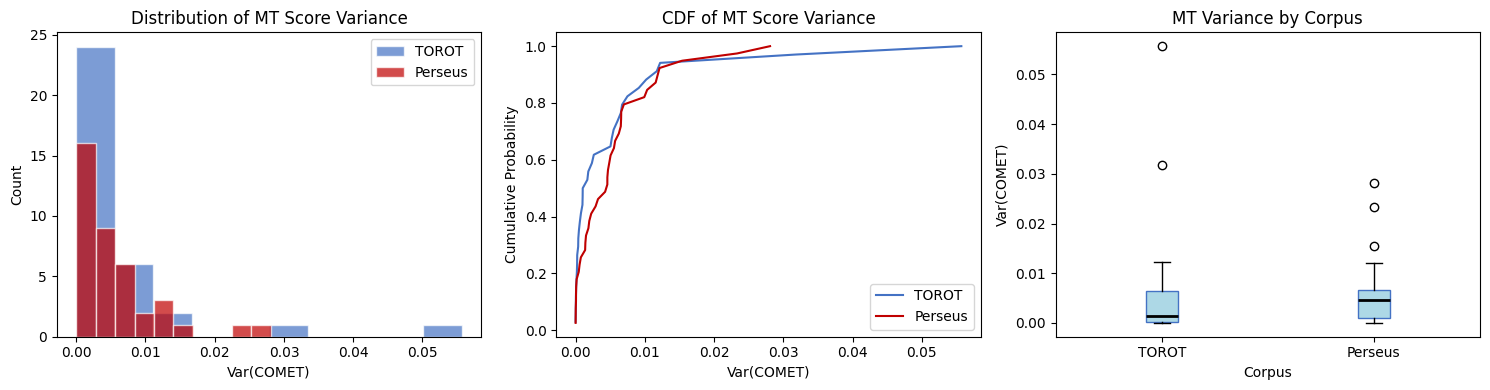

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

torot_var = df_sentences.loc[df_sentences['corpus']=='TOROT',   'var_mt'].dropna()
perseus_var = df_sentences.loc[df_sentences['corpus']=='Perseus', 'var_mt'].dropna()

# Histogram
ax = axes[0]
ax.hist(torot_var, bins=10, color=TOROT_COLOR, alpha=0.7, label='TOROT', edgecolor='white')
ax.hist(perseus_var, bins=10, color=PERSEUS_COLOR, alpha=0.7, label='Perseus', edgecolor='white')
ax.set_title('Distribution of MT Score Variance')
ax.set_xlabel('Var(COMET)')
ax.set_ylabel('Count')
ax.legend()

# CDF
ax = axes[1]
for data, label, color in [
    (torot_var, 'TOROT', TOROT_COLOR),
    (perseus_var, 'Perseus', PERSEUS_COLOR)
]:
    # Only plot if there is more than one unique value
    if data.nunique() > 1:
        s = np.sort(data)
        cdf = np.arange(1, len(s) + 1) / len(s)
        ax.plot(s, cdf, label=label, color=color)
    else:
        # Single unique value
        ax.axvline(data.iloc[0], color=color, label=f'{label} (constant)', linestyle='--')
ax.set_title('CDF of MT Score Variance')
ax.set_xlabel('Var(COMET)')
ax.set_ylabel('Cumulative Probability')
ax.legend()

# Boxplot
ax = axes[2]
ax.boxplot(
    [torot_var, perseus_var],
    labels=['TOROT', 'Perseus'],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue', color=TOROT_COLOR),
    medianprops=dict(color='black', linewidth=2)
)
ax.set_title('MT Variance by Corpus')
ax.set_xlabel('Corpus')
ax.set_ylabel('Var(COMET)')

plt.tight_layout()
plt.show()

## Statistical Testing

### Brown-Forsythe and Welch's t-test

Brown-Forsythe tests whether the spread of variance differs between corpora.

Welch's t-test tests whether the mean variance differs.

In [ ]:
# Brown-Forsythe (center='median' is the robust variant of Levene's)
bf_stat, bf_p = levene(torot_var, perseus_var, center='median')
print('Brown-Forsythe Test')
print(f'Statistic: {bf_stat:.4f}')
print(f'p-value: {bf_p:.4f}')
print(f'Result: {"Variances differ significantly (p<0.05)" if bf_p < 0.05 else "No significant difference in variance"}')

# Welch's t-test (does not assume equal variance between groups)
t_stat, t_p = stats.ttest_ind(torot_var, perseus_var, equal_var=False)
print('\nWelch\'s t-test')
print(f'Statistic: {t_stat:.4f}')
print(f'p-value: {t_p:.4f}')
print(f'Result: {"Mean variances differ significantly (p<0.05)" if t_p < 0.05 else "No significant difference in mean variance"}')

Brown-Forsythe Test
Statistic: 0.2818
p-value: 0.5972
Result: No significant difference in variance

Welch's t-test
Statistic: 0.0333
p-value: 0.9736
Result: No significant difference in mean variance


## Feature Analysis for Uncertainty Predictors
Aggregate token-level morphological information to sentence level.

- length: total token count (structural)
- punct_density: proportion of punctuation tokens (structural)
- case_density: proportion of tokens bearing a case feature (morphological)
- n_tags: number of distinct morphological tags (morphological complexity)
- tense_mood_diversity: distinct (tense, mood) combinations (morphological)
- pronoun_ratio: proportion of pronoun tokens (discourse)
- prodrop_indicator: 1 if verbal tokens present but no nominative pronoun (pro-drop)

In [ ]:
# Compute linguistic features per sentence
def compute_features(tok_df):
  feats = []
  for sid, grp in tok_df.groupby('sentence_id'):
      n = len(grp)

      # Structural
      token_count = n
      punct_density = (grp['pos'] == 'punctuation').sum() / n

      # Morphological
      case_density = grp['case'].notna().sum() / n
      n_tags = grp['tag'].nunique()
      verbal = grp.dropna(subset=['tense', 'mood'])
      tense_mood_diversity = verbal[['tense', 'mood']].drop_duplicates().shape[0]

      # Discourse / pro-drop
      pronoun_ratio = (grp['pos'].isin(['personal_pronoun', 'pronoun'])).sum() / n

      nom_pronoun = (
          (grp['pos'].isin(['personal_pronoun', 'pronoun'])) &
          (grp['case'] == 'nominative')
      ).sum()
      # Pro-drop: verbal tokens exist but subject pronoun is absent
      prodrop_indicator = int(nom_pronoun == 0 and verbal.shape[0] > 0)

      feats.append({
          'sentence_id': sid,
          'token_count': token_count,
          'punct_density': punct_density,
          'case_density': case_density,
          'n_tags': n_tags,
          'tense_mood_diversity': tense_mood_diversity,
          'pronoun_ratio': pronoun_ratio,
          'prodrop_indicator': prodrop_indicator,
      })
  return pd.DataFrame(feats)

df_features = compute_features(df_tokens)

# Merge into working DataFrame
df_model = df_sentences.merge(df_features, on='sentence_id', how='left')

# Binary corpus indicator: 0 = TOROT, 1 = Perseus
df_model['corpus_bin'] = (df_model['corpus'] == 'Perseus').astype(int)

print('Feature matrix shape:', df_model.shape)
print(df_model[['sentence_id', 'corpus', 'length', 'case_density',
                'tense_mood_diversity', 'pronoun_ratio',
                'prodrop_indicator']].head())

Feature matrix shape: (75, 21)
                sentence_id corpus  length  case_density  \
0  Primary_Chronicle_125275  TOROT      18      0.166667   
1  Primary_Chronicle_156453  TOROT      36      0.571429   
2  Primary_Chronicle_140937  TOROT      50      0.750000   
3  Primary_Chronicle_125278  TOROT      10      0.666667   
4  Primary_Chronicle_125279  TOROT      48      0.416667   

   tense_mood_diversity  pronoun_ratio  prodrop_indicator  
0                     0       0.000000                  0  
1                     1       0.000000                  1  
2                     1       0.125000                  1  
3                     0       0.333333                  0  
4                     2       0.250000                  0  


### Spearman correlation

Measures whether higher values of a feature consistently correspond to higher or lower COMET scores, without assuming linearity

In [ ]:
features = [
    'length', 'punct_density', 'case_density',
    'n_tags', 'tense_mood_diversity', 'pronoun_ratio',
    'prodrop_indicator', 'corpus_bin'
]
target = 'comet_nllb'

results = []
for feat in features:
    subset = df_model[[feat, target]].dropna()
    rho, p = spearmanr(subset[feat], subset[target])
    results.append({
        'Feature': feat,
        'rho': round(rho, 3),
        'p-value': round(p, 4),
    })

corr_df = (pd.DataFrame(results)
             .sort_values('rho', key=abs, ascending=False))
print(f'Spearman correlations with {target}:\n')
print(corr_df.to_string(index=False))

Spearman correlations with comet_nllb:

             Feature    rho  p-value
              length -0.360   0.0018
              n_tags -0.246   0.0363
tense_mood_diversity -0.197   0.0947
          corpus_bin -0.185   0.1170
       punct_density -0.170   0.1499
   prodrop_indicator  0.152   0.1995
        case_density  0.133   0.2609
       pronoun_ratio  0.043   0.7191


### Spearman bar chart

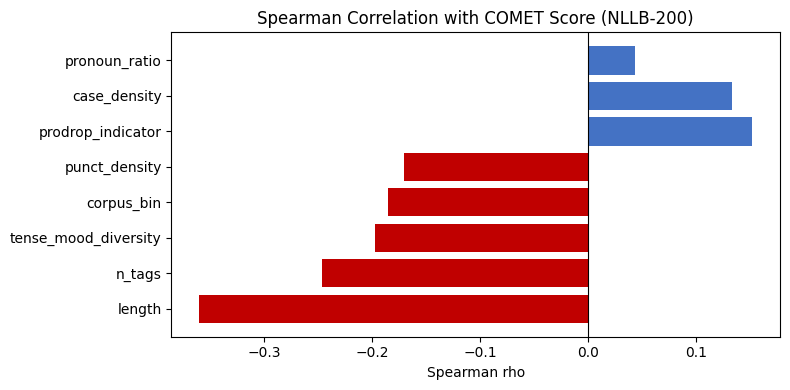

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = [PERSEUS_COLOR if r < 0 else TOROT_COLOR for r in corr_df['rho']]
ax.barh(corr_df['Feature'], corr_df['rho'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Spearman rho')
ax.set_title('Spearman Correlation with COMET Score (NLLB-200)')
plt.tight_layout()
plt.show()

### Linear regression
Models COMET score as a linear function of the linguistic features. Standardised coefficients show the relative contribution of each feature to translation uncertainty.

In [ ]:
formula = (
    'comet_nllb ~ length + case_density + tense_mood_diversity + pronoun_ratio + prodrop_indicator + corpus_bin'
)
lm = smf.ols(formula, data=df_model.dropna(subset=['comet_nllb'])).fit()
print(lm.summary())

                            OLS Regression Results                            
Dep. Variable:             comet_nllb   R-squared:                       0.197
Model:                            OLS   Adj. R-squared:                  0.124
Method:                 Least Squares   F-statistic:                     2.706
Date:                Mon, 06 Apr 2026   Prob (F-statistic):             0.0207
Time:                        18:39:03   Log-Likelihood:                 105.01
No. Observations:                  73   AIC:                            -196.0
Df Residuals:                      66   BIC:                            -180.0
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.4247 

###  Mixed-effects model

TOROT sentences share structural properties with each other that are distinct from Perseus sentences. The corpus is treated as the grouping variable (random effect).

In [ ]:
me_formula = (
    'comet_nllb ~ length + case_density + tense_mood_diversity + pronoun_ratio + prodrop_indicator'
)
me_model = smf.mixedlm(
    me_formula,
    data=df_model.dropna(subset=['comet_nllb']),
    groups=df_model.dropna(subset=['comet_nllb'])['corpus']
).fit()
print(me_model.summary())

             Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   comet_nllb
No. Observations:    73        Method:               REML      
No. Groups:          2         Scale:                0.0036    
Min. group size:     34        Log-Likelihood:       81.7167   
Max. group size:     39        Converged:            Yes       
Mean group size:     36.5                                      
---------------------------------------------------------------
                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept             0.425    0.029 14.695 0.000  0.368  0.482
length               -0.000    0.000 -2.109 0.035 -0.001 -0.000
case_density         -0.000    0.030 -0.003 0.997 -0.059  0.059
tense_mood_diversity -0.002    0.009 -0.232 0.816 -0.021  0.016
pronoun_ratio         0.089    0.065  1.364 0.173 -0.039  0.216
prodrop_indicator     0.049    0.025  1.953 0.051 -0.

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


## Evaluation Metric Sensitivity Across Corpora


### Compute Δ_metric

Δ_metric = COMET − BLEU_normalised per sentence.
A large positive Δ means COMET scores the translation well but BLEU does not and that the fingerprint of surface-form metric bias rather than actual translation failure.

In [ ]:
# Normalise BLEU from [0,100] to [0,1] to make it comparable to COMET
df_model['bleu_nllb_norm']   = df_model['bleu_nllb']   / 100
df_model['bleu_marian_norm'] = df_model['bleu_marian'] / 100

# delta metric
df_model['delta_nllb'] = df_model['comet_nllb'] - df_model['bleu_nllb_norm']
df_model['delta_marian'] = df_model['comet_marian'] - df_model['bleu_marian_norm']

print('Mean Δ_metric by corpus (NLLB-200):')
print(df_model.groupby('corpus')['delta_nllb'].describe().round(3))
print('\nMean Δ_metric by corpus (MarianMT):')
print(df_model.groupby('corpus')['delta_marian'].describe().round(3))

Mean Δ_metric by corpus (NLLB-200):
         count   mean    std    min    25%    50%    75%    max
corpus                                                         
Perseus   39.0  0.411  0.054  0.293  0.378  0.415  0.443  0.540
TOROT     34.0  0.408  0.063  0.289  0.348  0.411  0.457  0.525

Mean Δ_metric by corpus (MarianMT):
         count   mean    std    min    25%   50%    75%    max
corpus                                                        
Perseus   39.0  0.451  0.088  0.235  0.414  0.44  0.489  0.692
TOROT     34.0  0.393  0.082  0.226  0.348  0.38  0.434  0.555


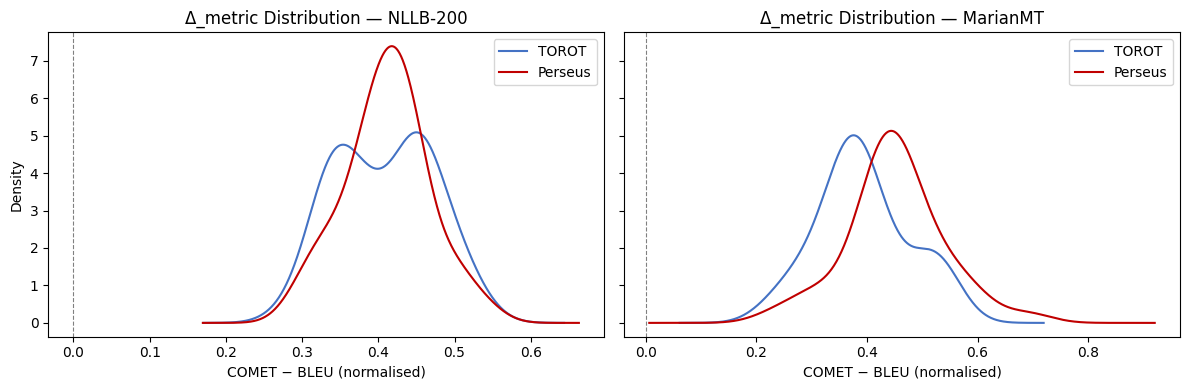

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, system, col in [
    (axes[0], 'NLLB-200', 'delta_nllb'),
    (axes[1], 'MarianMT', 'delta_marian')
]:
    for corpus, color in [('TOROT', TOROT_COLOR), ('Perseus', PERSEUS_COLOR)]:
        subset = df_model.loc[df_model['corpus'] == corpus, col].dropna()
        subset.plot.kde(ax=ax, label=corpus, color=color)
    ax.axvline(0, color='grey', linestyle='--', linewidth=0.8)
    ax.set_title(f'Δ_metric Distribution — {system}')
    ax.set_xlabel('COMET − BLEU (normalised)')
    ax.legend()

plt.tight_layout()
plt.show()

### Stratification by corpus and morphological complexity

In [ ]:
# Mean scores per corpus
strat = df_model.groupby('corpus').agg(
    mean_bleu_nllb    = ('bleu_nllb',    'mean'),
    var_bleu_nllb     = ('bleu_nllb',    'var'),
    mean_comet_nllb   = ('comet_nllb',   'mean'),
    var_comet_nllb    = ('comet_nllb',   'var'),
    mean_bleu_marian  = ('bleu_marian',  'mean'),
    mean_comet_marian = ('comet_marian', 'mean'),
).round(3)
print('Stratified mean scores by corpus:')
print(strat)

Stratified mean scores by corpus:
         mean_bleu_nllb  var_bleu_nllb  mean_comet_nllb  var_comet_nllb  \
corpus                                                                    
Perseus           2.175          2.994            0.433           0.003   
TOROT             5.169         18.219            0.460           0.005   

         mean_bleu_marian  mean_comet_marian  
corpus                                        
Perseus             5.328              0.504  
TOROT               3.758              0.431  


In [ ]:
case_min = df_model['case_density'].min()
case_max = df_model['case_density'].max()
case_mid1 = df_model['case_density'].quantile(0.33)
case_mid2 = df_model['case_density'].quantile(0.66)

print(f'\nBoundaries: {case_min:.3f} | {case_mid1:.3f} | {case_mid2:.3f} | {case_max:.3f}')


Boundaries: 0.000 | 0.000 | 0.427 | 0.750


In [ ]:
# Only bin if the boundaries are actually distinct
if len({case_min, case_mid1, case_mid2, case_max}) >= 3:
    df_model['case_density_bin'] = pd.cut(
        df_model['case_density'],
        bins=[case_min - 0.001, case_mid1, case_mid2, case_max + 0.001],
        labels=['low', 'mid', 'high']
    )
else:
    # Fallback: just split at the median
    median = df_model['case_density'].median()
    df_model['case_density_bin'] = df_model['case_density'].apply(
        lambda x: 'low' if x <= median else 'high'
    )

print('\nBin distribution:')
print(df_model['case_density_bin'].value_counts())

strat2 = df_model.groupby(['corpus', 'case_density_bin']).agg(
    mean_bleu  = ('bleu_nllb',   'mean'),
    mean_comet = ('comet_nllb',  'mean'),
    n          = ('sentence_id', 'count')
).round(3)
print('\nStratified by corpus × case density:')
print(strat2)


Bin distribution:
case_density_bin
low     42
high    26
mid      7
Name: count, dtype: int64

Stratified by corpus × case density:
                          mean_bleu  mean_comet   n
corpus  case_density_bin                           
Perseus low                   2.175       0.433  40
        mid                     NaN         NaN   0
        high                    NaN         NaN   0
TOROT   low                   5.200       0.453   2
        mid                   3.605       0.437   7
        high                  5.605       0.467  26


/tmp/ipykernel_15959/1497845326.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  strat2 = df_model.groupby(['corpus', 'case_density_bin']).agg(


### Grouped bar chart: BLEU vs COMET by corpus

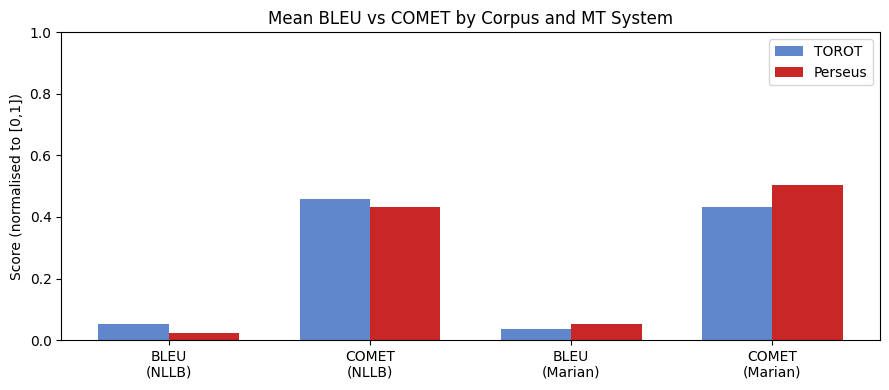

In [ ]:
metrics = ['mean_bleu_nllb', 'mean_comet_nllb', 'mean_bleu_marian', 'mean_comet_marian']
labels  = ['BLEU\n(NLLB)', 'COMET\n(NLLB)', 'BLEU\n(Marian)', 'COMET\n(Marian)']

x = np.arange(len(metrics))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 4))

torot_vals = strat.loc['TOROT',   metrics].values.astype(float)
perseus_vals = strat.loc['Perseus', metrics].values.astype(float)

# Normalise BLEU columns to [0,1] so they sit on the same axis as COMET
for i, m in enumerate(metrics):
    if 'bleu' in m:
        torot_vals[i] /= 100
        perseus_vals[i] /= 100

ax.bar(x - width/2, torot_vals,   width, label='TOROT',   color=TOROT_COLOR,   alpha=0.85)
ax.bar(x + width/2, perseus_vals, width, label='Perseus', color=PERSEUS_COLOR, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Score (normalised to [0,1])')
ax.set_title('Mean BLEU vs COMET by Corpus and MT System')
ax.set_ylim(0, 1)
ax.legend()

plt.tight_layout()
plt.show()

### Bootstrap resampling

Resamples the mean score difference between corpora 1000 times. If the 95% confidence interval excludes zero for BLEU but not for COMET, this is the strongest evidence that the penalty is metric-driven rather than a real quality difference.

δ(b) = mean(A) - mean(B)

In [ ]:
def bootstrap_mean_diff(group_a, group_b, B=1000, seed=42):
    rng = np.random.default_rng(seed)
    obs_diff = group_a.mean() - group_b.mean()
    diffs = [
        rng.choice(group_a, len(group_a), replace=True).mean() -
        rng.choice(group_b, len(group_b), replace=True).mean()
        for _ in range(B)
    ]
    diffs = np.array(diffs)
    ci_low = np.percentile(diffs, 2.5)
    ci_high = np.percentile(diffs, 97.5)
    p_val = np.mean(np.abs(diffs) >= np.abs(obs_diff))
    return obs_diff, ci_low, ci_high, p_val

torot_bleu = df_model.loc[df_model['corpus']=='TOROT', 'bleu_nllb'].dropna()
perseus_bleu = df_model.loc[df_model['corpus']=='Perseus', 'bleu_nllb'].dropna()
torot_comet = df_model.loc[df_model['corpus']=='TOROT', 'comet_nllb'].dropna()
perseus_comet = df_model.loc[df_model['corpus']=='Perseus', 'comet_nllb'].dropna()

for name, g_a, g_b in [
    ('BLEU  (NLLB)', torot_bleu,  perseus_bleu),
    ('COMET (NLLB)', torot_comet, perseus_comet),
]:
    diff, lo, hi, p = bootstrap_mean_diff(g_a.values, g_b.values)
    sig = '*** significant' if p < 0.05 else 'not significant'
    print(f'{name}: obs_diff={diff:+.3f},  95% CI=[{lo:.3f}, {hi:.3f}], p={p:.3f}  ({sig})')

BLEU  (NLLB): obs_diff=+2.995,  95% CI=[1.420, 4.446], p=0.481  (not significant)
COMET (NLLB): obs_diff=+0.027,  95% CI=[-0.003, 0.057], p=0.497  (not significant)


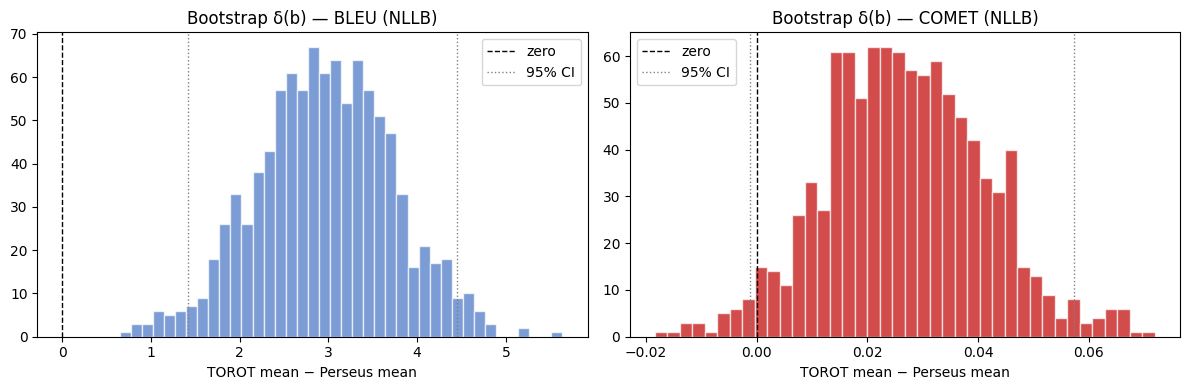

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
rng = np.random.default_rng(42)

for ax, name, g_a, g_b, color in [
    (axes[0], 'BLEU (NLLB)',  torot_bleu,  perseus_bleu,  TOROT_COLOR),
    (axes[1], 'COMET (NLLB)', torot_comet, perseus_comet, PERSEUS_COLOR),
]:
    diffs = [
        rng.choice(g_a.values, len(g_a), replace=True).mean() -
        rng.choice(g_b.values, len(g_b), replace=True).mean()
        for _ in range(1000)
    ]
    ax.hist(diffs, bins=40, color=color, alpha=0.7, edgecolor='white')
    ax.axvline(0, color='black', linestyle='--', linewidth=1, label='zero')
    ax.axvline(np.percentile(diffs, 2.5),  color='grey', linestyle=':', linewidth=1)
    ax.axvline(np.percentile(diffs, 97.5), color='grey', linestyle=':',
               linewidth=1, label='95% CI')
    ax.set_title(f'Bootstrap δ(b) — {name}')
    ax.set_xlabel('TOROT mean − Perseus mean')
    ax.legend()

plt.tight_layout()
plt.show()

### Brown-Forsythe on score spread

In [ ]:
print('Brown-Forsythe: BLEU score spread')
bf_b, bf_bp = levene(torot_bleu, perseus_bleu, center='median')
print(f'  Statistic={bf_b:.4f},  p={bf_bp:.4f}')

print('\nBrown-Forsythe: COMET score spread')
bf_c, bf_cp = levene(torot_comet, perseus_comet, center='median')
print(f'  Statistic={bf_c:.4f},  p={bf_cp:.4f}')

print('\nInterpretation')
if bf_bp < 0.05 and bf_cp >= 0.05:
    print('BLEU spread differs and COMET does not  =>  surface-form metric bias.')
elif bf_bp < 0.05 and bf_cp < 0.05:
    print('Both metrics differ  =>  genuine translation difficulty.')
else:
    print('Neither metric shows a significant spread difference.')


Brown-Forsythe: BLEU score spread
  Statistic=22.8169,  p=0.0000

Brown-Forsythe: COMET score spread
  Statistic=0.6277,  p=0.4308

Interpretation
BLEU spread differs; COMET does not  =>  surface-form metric bias.
